In [190]:
import numpy as np
import gymnasium as gym
import importlib
import envs

import learners
import analysis
importlib.reload(analysis)
importlib.reload(learners)
from learners import *
from analysis import *

params = Params(
    model_name="WindyRooms",
    n_runs=5,
    n_episodes=50_000,
    save_skip=50,
    lr_decay=None,
    seed=123,
    
    N=32,
    # alpha=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0,1.2,1.5,1.8,2.0,5.0],
    alpha=None,
    gamma=0.99,
    epsilon=0.0,
    
    nA=None,
    nS=None,
    shape=None,
)
rng = np.random.default_rng(params.seed)
tau = (np.arange(params.N) + 0.5) / params.N
env = gym.make(params.model_name)
params = params._replace(nA=int(env.action_space.n))
params = params._replace(nS=int(env.observation_space.n))
params = params._replace(shape=env.unwrapped.shape)
s_init, _ = env.reset()

save_to = None
# save_to = "experiments/"+params.model_name

In [183]:
policy, V_pi = PolicyIteration(env, params.gamma)
explorer = EpsilonGreedy(params.epsilon, rng)

def scheduler(alpha, ep): return alpha / (0.5*ep+1)**0.5
def get_scheduler(val): return lambda alpha, ep: alpha / (val*ep+1)**0.5

table_qr = QR(0, params._replace(alpha=1.0), policy).train(env, explorer, get_scheduler(0.05))
table_q = Qlearner(params._replace(alpha=1.0), policy).train(env, explorer, get_scheduler(0.05))

100%|██████████| 250000/250000 [06:08<00:00, 678.17it/s, ep=5e+4, run=5] 


In [184]:
returns = MonteCarlo(env, policy, params.gamma, total_episodes=10_000)
tau_returns = np.quantile(np.sort(returns), tau)

  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [00:01<00:00, 5816.27it/s]


In [192]:
table_td = TD(params._replace(alpha=1.0), policy).train(env, explorer, get_scheduler(0.05))
table_qrtd = QRTD(0, params._replace(alpha=1.0), policy).train(env, explorer, get_scheduler(0.05))

100%|██████████| 250000/250000 [08:50<00:00, 471.22it/s, ep=5e+4, run=5] 


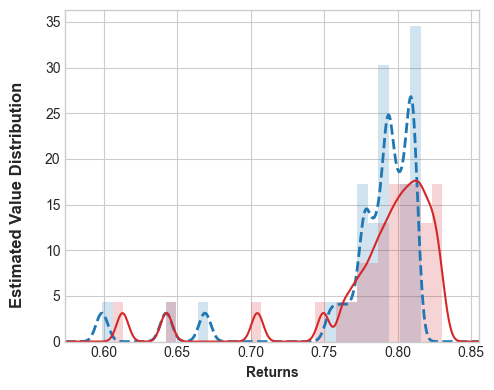

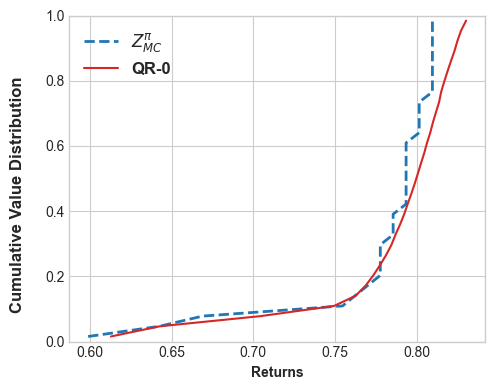

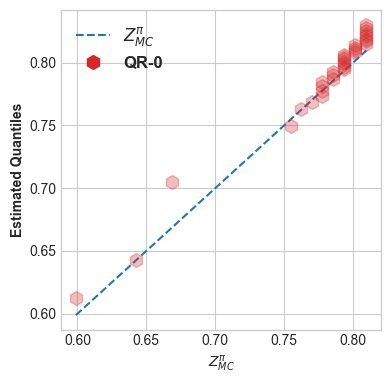

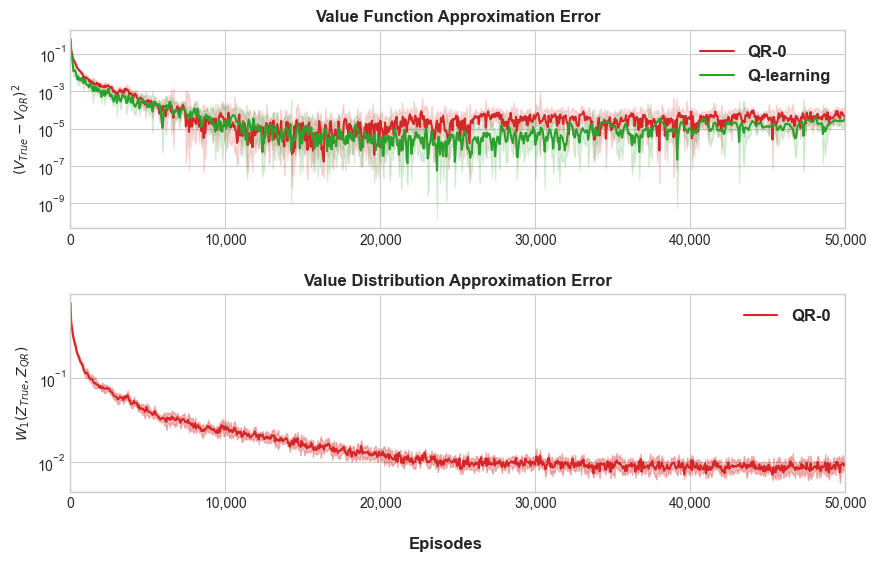

In [195]:
def get_q(table): return table[:,:,s_init].max(2)
def get_best(table): return get_q(table)[:,-1].mean(0)

plot_objs = [
    (get_best(table_qr), "QR-0"),
]
plot_qs = [
    (get_q(table_qr), "QR-0"),
    (get_q(table_q), "Q-learning"),
]

LOW_BANDWIDTH = 0.004
bw = LOW_BANDWIDTH
plot_pdf(plot_objs, tau_returns, bandwidth=bw, show_hist=True, N=params.N, save_to=save_to)
plot_cdf(plot_objs, tau_returns, tau, save_to=save_to)
plot_qq(plot_objs, tau_returns, save_to=save_to)
plot_metrics(plot_qs, tau_returns, save_skip=params.save_skip, save_to=save_to, alphas=[0.15,0.3])